In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
data = pd.read_csv('student_data.csv')
data = data.dropna().reset_index(drop=True)

In [3]:
#Target
data['Final_Result'] = ((data[['G1', 'G2', 'G3']] >= 10).all(axis=1)).astype(int)

In [4]:
#Drop Unnecessary Columns
drop_cols = [
    'famsize','Pstatus','Medu','Fedu','higher','famrel',
    'Dalc','Walc','address','Mjob','Fjob','school','nursery'
]
drop_cols = [col for col in drop_cols if col in data.columns]
data = data.drop(columns=drop_cols)

In [5]:
#Encoding
label_encoders = {}
for col in data.select_dtypes(include='object').columns:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col])
    label_encoders[col] = le

In [6]:
#Train Test Split
X = data.drop(columns=['Final_Result'])
y = data['Final_Result']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [7]:
#Feature Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [8]:
#Models
models = [
    ("(4,4) - tanh",
     MLPClassifier(hidden_layer_sizes=(4,4),
                   activation='tanh',
                   max_iter=1000,
                   random_state=42)),

    ("(10,8,4) - tanh",
     MLPClassifier(hidden_layer_sizes=(10,8,4),
                   activation='tanh',
                   max_iter=1000,
                   random_state=42)),

    ("(4,4) - logistic",
     MLPClassifier(hidden_layer_sizes=(4,4),
                   activation='logistic',
                   max_iter=1000,
                   random_state=42)),

    ("(10,8,4) - logistic",
     MLPClassifier(hidden_layer_sizes=(10,8,4),
                   activation='logistic',
                   max_iter=1000,
                   random_state=42))
]


In [9]:
#Training & Evaluation
results = {}

for name, model in models:
    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)

    results[name] = {
        "train_accuracy": train_acc,
        "test_accuracy": test_acc,
        "model": model
    }

    print(f"Model: {name}")
    print(f"Train Accuracy: {train_acc:.4f}")
    print(f"Test Accuracy : {test_acc:.4f}")
    print("-" * 40)

Model: (4,4) - tanh
Train Accuracy: 1.0000
Test Accuracy : 0.9494
----------------------------------------
Model: (10,8,4) - tanh
Train Accuracy: 1.0000
Test Accuracy : 0.9620
----------------------------------------


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


Model: (4,4) - logistic
Train Accuracy: 0.9968
Test Accuracy : 0.9494
----------------------------------------
Model: (10,8,4) - logistic
Train Accuracy: 1.0000
Test Accuracy : 0.9367
----------------------------------------


In [10]:
#Best Model
best_model_name = max(results, key=lambda x: results[x]["test_accuracy"])
best_model = results[best_model_name]["model"]
best_acc = results[best_model_name]["test_accuracy"]

print("\n Best Model:", best_model_name)
print(" Best Test Accuracy:", best_acc)


 Best Model: (10,8,4) - tanh
 Best Test Accuracy: 0.9620253164556962


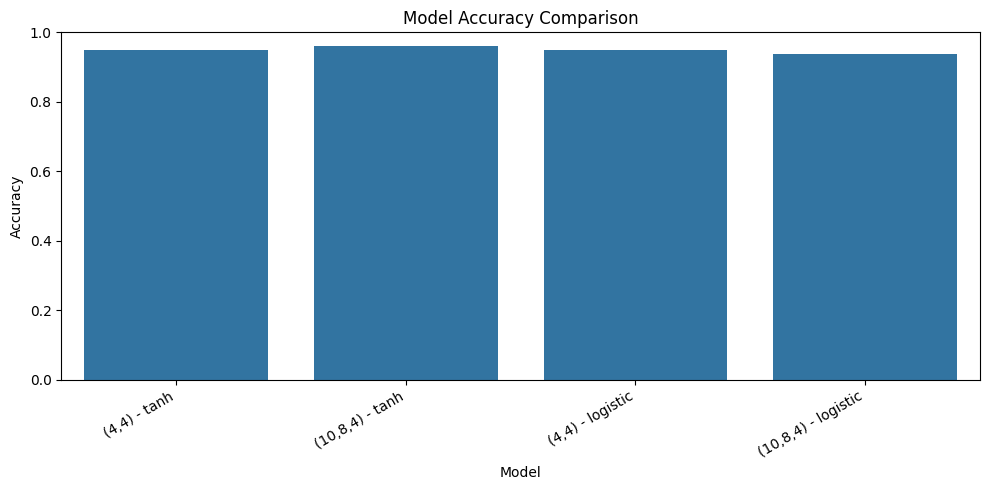

In [11]:
#Accuracy Comparison Bar Chart
model_names = list(results.keys())
test_accuracies = [results[m]["test_accuracy"] for m in model_names]

plt.figure(figsize=(10,5))
sns.barplot(x=model_names, y=test_accuracies)
plt.xticks(rotation=30, ha='right')
plt.ylabel("Accuracy")
plt.xlabel("Model")
plt.title("Model Accuracy Comparison")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

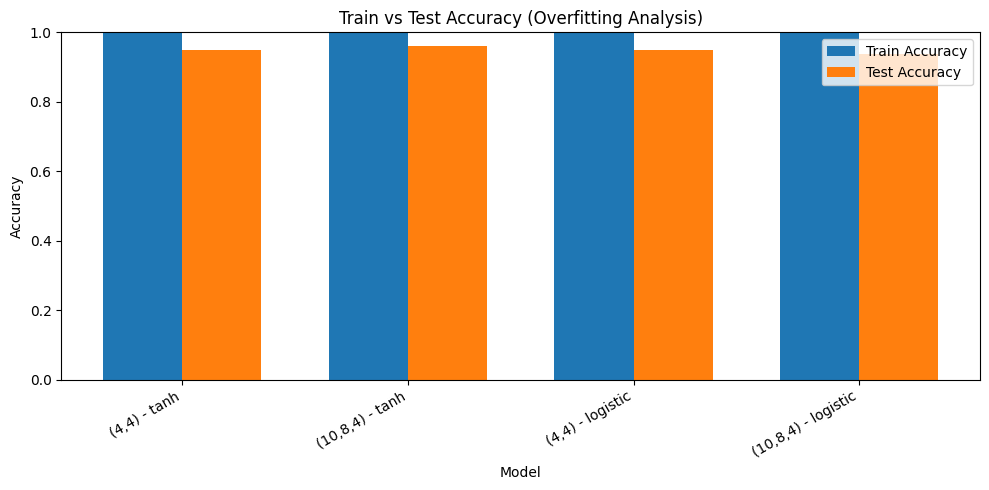

In [12]:
#Overfitting Analysis
train_accuracies = [results[m]["train_accuracy"] for m in model_names]

x = np.arange(len(model_names))
width = 0.35

plt.figure(figsize=(10,5))
plt.bar(x - width/2, train_accuracies, width, label='Train Accuracy')
plt.bar(x + width/2, test_accuracies, width, label='Test Accuracy')

plt.xticks(x, model_names, rotation=30, ha='right')
plt.ylabel("Accuracy")
plt.xlabel("Model")
plt.title("Train vs Test Accuracy (Overfitting Analysis)")
plt.legend()
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

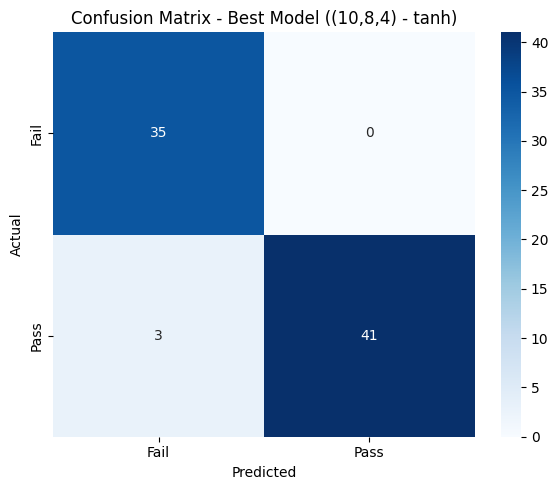

In [13]:
#Confusion Matrix for Best Model
y_best_pred = best_model.predict(X_test)
cm = confusion_matrix(y_test, y_best_pred)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Fail', 'Pass'],
    yticklabels=['Fail', 'Pass']
)
plt.title(f"Confusion Matrix - Best Model ({best_model_name})")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

In [14]:
#Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_best_pred, target_names=['Fail', 'Pass']))


Classification Report:
              precision    recall  f1-score   support

        Fail       0.92      1.00      0.96        35
        Pass       1.00      0.93      0.96        44

    accuracy                           0.96        79
   macro avg       0.96      0.97      0.96        79
weighted avg       0.97      0.96      0.96        79

